#CONNECT DRIVE

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# RANDOM FOREST MODEL

import & setup

In [2]:
import os
import time
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)

model

In [3]:
def train_randomforest(file_path, station_name, use_shap=False):
    print(f"Xử lý trạm: {station_name}")

    if not os.path.exists(file_path):
        print(f"Lỗi: Không tìm thấy file {file_path}")
        return

    df = pd.read_csv(file_path) # đọc và setup data
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)

    target_col = 'wind_speed' # vì 1 bước nhảy = 15 phút, nên so với yêu cầu để bài ta sẽ nhảy các bước 2, 4, 8
    df['target_30min']  = df[target_col].shift(-2)
    df['target_60min']  = df[target_col].shift(-4)
    df['target_120min'] = df[target_col].shift(-8)
    df = df.dropna()

    target_cols = ['target_30min', 'target_60min', 'target_120min']
    Y = df[target_cols]
    X = df.drop(columns=target_cols)

    n = len(df)
    train_end = int(n * 0.7)
    val_end = int(n * 0.85)

    X_train, Y_train = X.iloc[:train_end], Y.iloc[:train_end]
    X_val, Y_val     = X.iloc[train_end:val_end], Y.iloc[train_end:val_end]
    X_test, Y_test   = X.iloc[val_end:], Y.iloc[val_end:]

    print(f"Kích thước tập - Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

    # train model
    rf = RandomForestRegressor(
        n_estimators=150, max_depth=15, min_samples_split=5,
        min_samples_leaf=2, max_features='sqrt', random_state=42, n_jobs=-1
    )

    print("\nĐang huấn luyện mô hình...")
    start_time = time.time()
    rf.fit(X_train, Y_train)
    print(f"Thời gian huấn luyện: {time.time() - start_time:.2f}s")

    # đánh giá
    start_time = time.time()
    y_pred = rf.predict(X_test)
    latency_full = ((time.time() - start_time) / len(X_test)) * 1000 # Lưu lại cho Bảng 8

    print("\nResult test")
    print(f"Độ trễ suy luận trung bình (Latency): {latency_full:.4f} ms/mẫu")

    rmse_full_30m = 0 # lưu riêng RMSE 30p để so sánh ở Bảng 8
    for i, col in enumerate(target_cols):
        rmse = np.sqrt(mean_squared_error(Y_test[col], y_pred[:, i]))
        mae  = mean_absolute_error(Y_test[col], y_pred[:, i])
        r2   = r2_score(Y_test[col], y_pred[:, i])
        print(f"Horizon {col}: RMSE = {rmse:.4f} | MAE = {mae:.4f} | R2 = {r2:.4f}")
        if col == 'target_30min':
            rmse_full_30m = rmse

    overall_rmse = np.sqrt(mean_squared_error(Y_test[target_cols], y_pred))
    print(f"\nGlobal RMSE (All Horizons): {overall_rmse:.4f}")

    # phân tích SHAP và future selection (bảng 8)
    if use_shap:
        print("\nĐang khởi tạo phân tích...")
        try:
            # Tính toán SHAP 1 lần duy nhất
            X_sample = shap.utils.sample(X_test, 500)
            explainer = shap.TreeExplainer(rf)
            shap_values_raw = explainer.shap_values(X_sample)
            is_new_shap = not isinstance(shap_values_raw, list) and len(shap_values_raw.shape) == 3

            horizons = ['30 Phút', '60 Phút', '120 Phút']
            for i in range(3):
                print(f"\nVẽ biểu đổ SHAP cho mốc: {horizons[i]}")
                sv = shap_values_raw[:, :, i] if is_new_shap else shap_values_raw[i]

                # hình 9
                plt.figure(figsize=(8, 5))
                plt.title(f"Top Features Importance - {station_name} ({horizons[i]})")
                shap.summary_plot(sv, X_sample, plot_type="bar", show=False)
                plt.show()

                # hình 10
                plt.figure(figsize=(10, 6))
                plt.title(f"SHAP Distribution - {station_name} ({horizons[i]})")
                shap.summary_plot(sv, X_sample, plot_type="dot", show=False)
                plt.show()

                # hình 11
                errors = np.abs(Y_test.iloc[:500, i].values - y_pred[:500, i])
                worst_idx = np.argmax(errors)
                print(f"Phân tích mẫu sai số lớn nhất (Index: {worst_idx}, Error: {errors[worst_idx]:.4f})")

                exp = shap.Explanation(
                    values=sv[worst_idx], base_values=explainer.expected_value[i],
                    data=X_sample.iloc[worst_idx], feature_names=X.columns.tolist()
                )

                plt.figure(figsize=(10, 6))
                plt.title(f"Local Explanation (Worst Case) - {horizons[i]}")
                shap.plots.waterfall(exp, show=False)
                plt.show()

            # Future selection (bảng 8)
            print("\nFuture selection")

            # Lấy SHAP của mốc 30 phút để xếp hạng biến
            sv_30m = shap_values_raw[:, :, 0] if is_new_shap else shap_values_raw[0]
            importance = np.abs(sv_30m).mean(axis=0)
            top_10_idx = np.argsort(importance)[::-1][:10]
            top_10_features = X.columns[top_10_idx].tolist()

            print(f"Top 10 biến quan trọng nhất: \n{top_10_features}\n")

            # Tạo tập dữ liệu thu gọn
            X_train_top10 = X_train[top_10_features]
            X_test_top10 = X_test[top_10_features]

            # Huấn luyện lại mô hình tối giản
            rf_lite = RandomForestRegressor(
                n_estimators=150, max_depth=15, min_samples_split=5,
                min_samples_leaf=2, max_features='sqrt', random_state=42, n_jobs=-1
            )
            rf_lite.fit(X_train_top10, Y_train)

            # Đánh giá mô hình tối giản
            start_time = time.time()
            y_pred_lite = rf_lite.predict(X_test_top10)
            latency_lite = ((time.time() - start_time) / len(X_test_top10)) * 1000
            rmse_lite_30m = np.sqrt(mean_squared_error(Y_test['target_30min'], y_pred_lite[:, 0]))

            print("[Kết quả so sánh hiệu năng - mốc 30min")
            print(f"1. Mô hình Gốc (All Features): RMSE = {rmse_full_30m:.4f} | Latency = {latency_full:.4f} ms")
            print(f"2. Mô hình Lite (Top 10)     : RMSE = {rmse_lite_30m:.4f} | Latency = {latency_lite:.4f} ms")

            # Tính phần trăm cải thiện
            lat_diff = ((latency_full - latency_lite) / latency_full) * 100
            print(f"-> Độ trễ suy luận giảm được: {lat_diff:.2f}%")

        except Exception as e:
            print(f"Lỗi khi chạy XAI/Feature Selection: {e}")

running

Xử lý trạm: Tram_A_DatLien
Kích thước tập - Train: 73626 | Val: 15777 | Test: 15778

Đang huấn luyện mô hình...
Thời gian huấn luyện: 53.47s

Result test
Độ trễ suy luận trung bình (Latency): 0.0207 ms/mẫu
Horizon target_30min: RMSE = 0.2479 | MAE = 0.1374 | R2 = 0.9847
Horizon target_60min: RMSE = 0.4263 | MAE = 0.2805 | R2 = 0.9548
Horizon target_120min: RMSE = 0.7367 | MAE = 0.5433 | R2 = 0.8649

Global RMSE (All Horizons): 0.5118

Đang khởi tạo phân tích...

Vẽ biểu đổ SHAP cho mốc: 30 Phút


/tmp/ipykernel_490/749460926.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="bar", show=False)


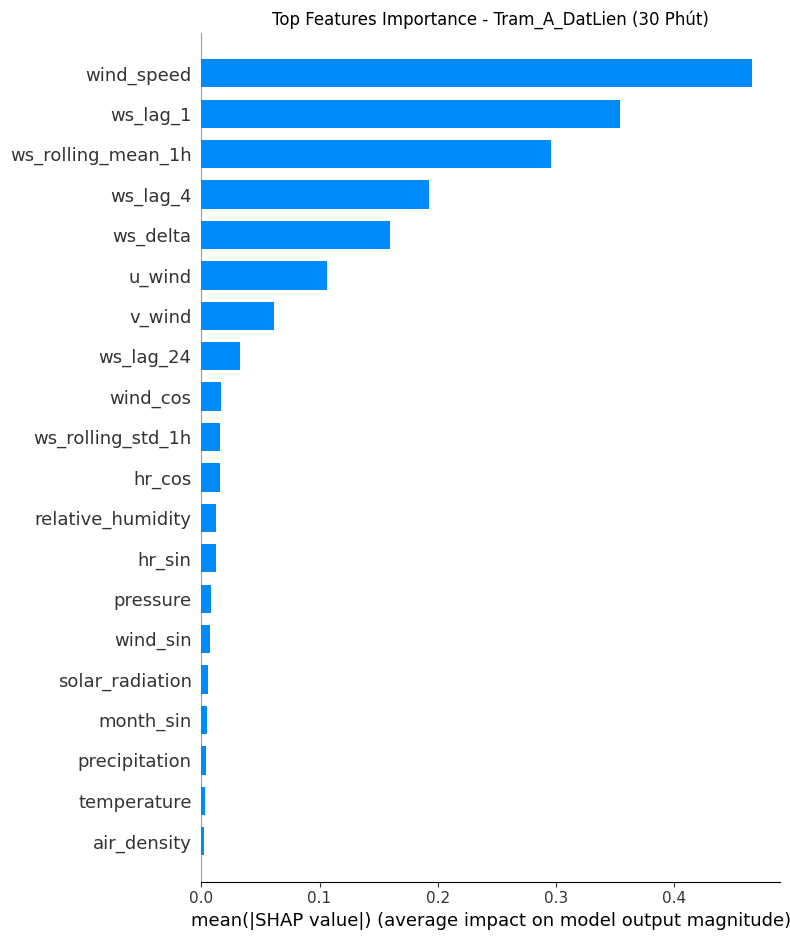

/tmp/ipykernel_490/749460926.py:87: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="dot", show=False)


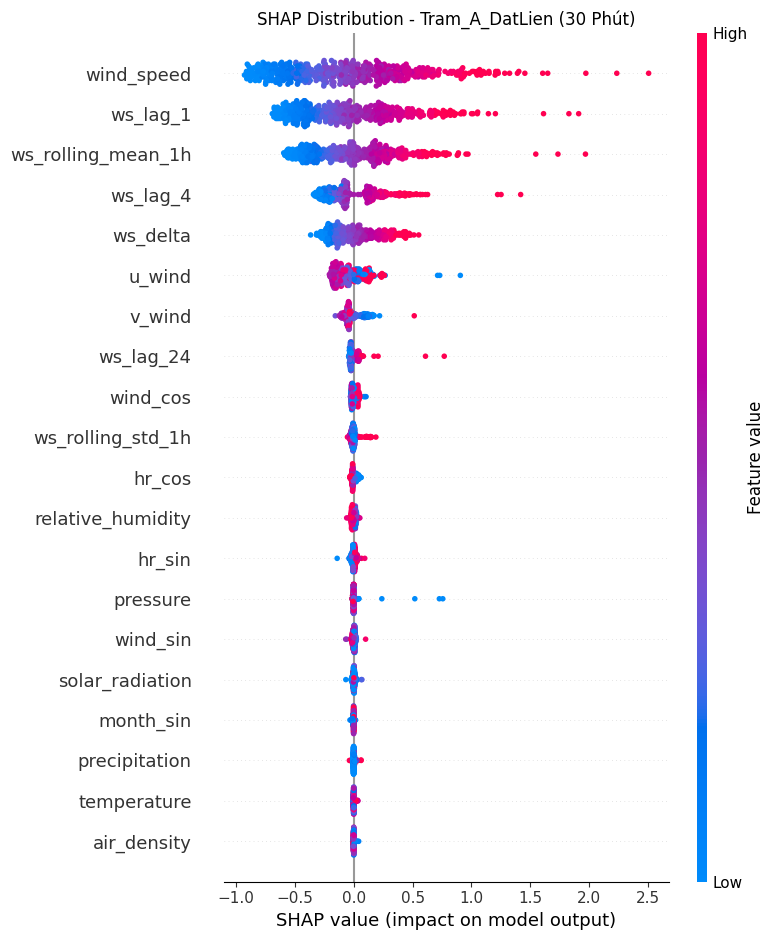

Phân tích mẫu sai số lớn nhất (Index: 106, Error: 2.1319)


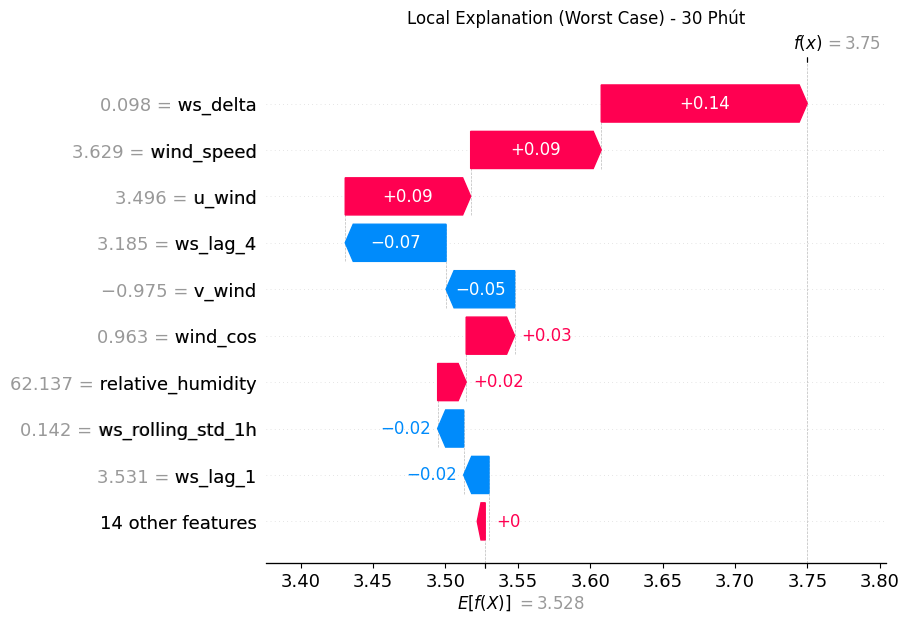


Vẽ biểu đổ SHAP cho mốc: 60 Phút


/tmp/ipykernel_490/749460926.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="bar", show=False)


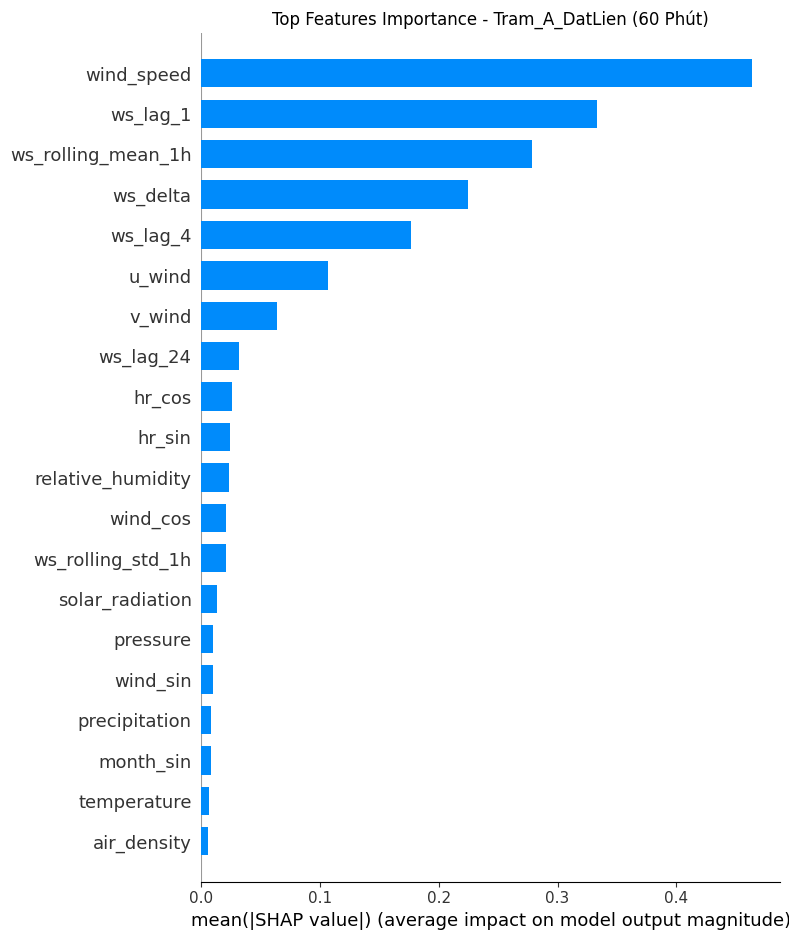

/tmp/ipykernel_490/749460926.py:87: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="dot", show=False)


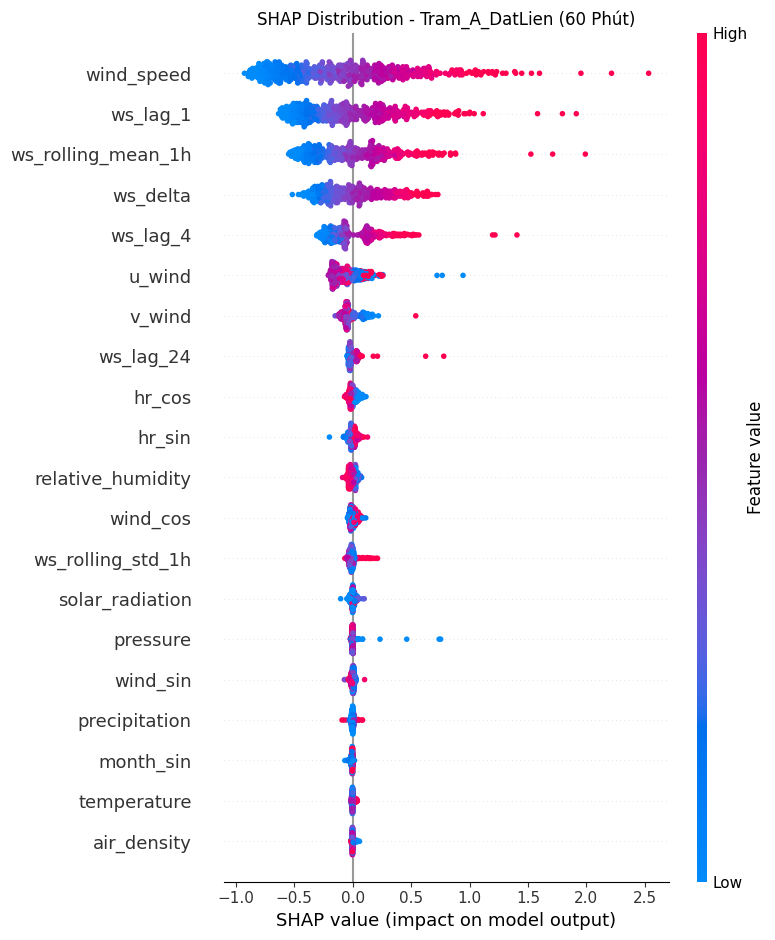

Phân tích mẫu sai số lớn nhất (Index: 104, Error: 2.9976)


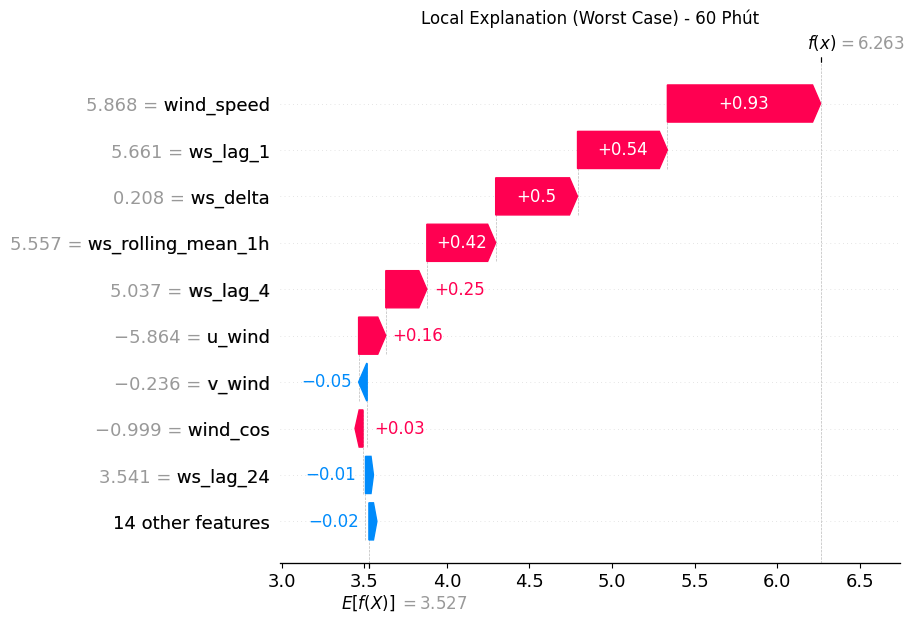


Vẽ biểu đổ SHAP cho mốc: 120 Phút


/tmp/ipykernel_490/749460926.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="bar", show=False)


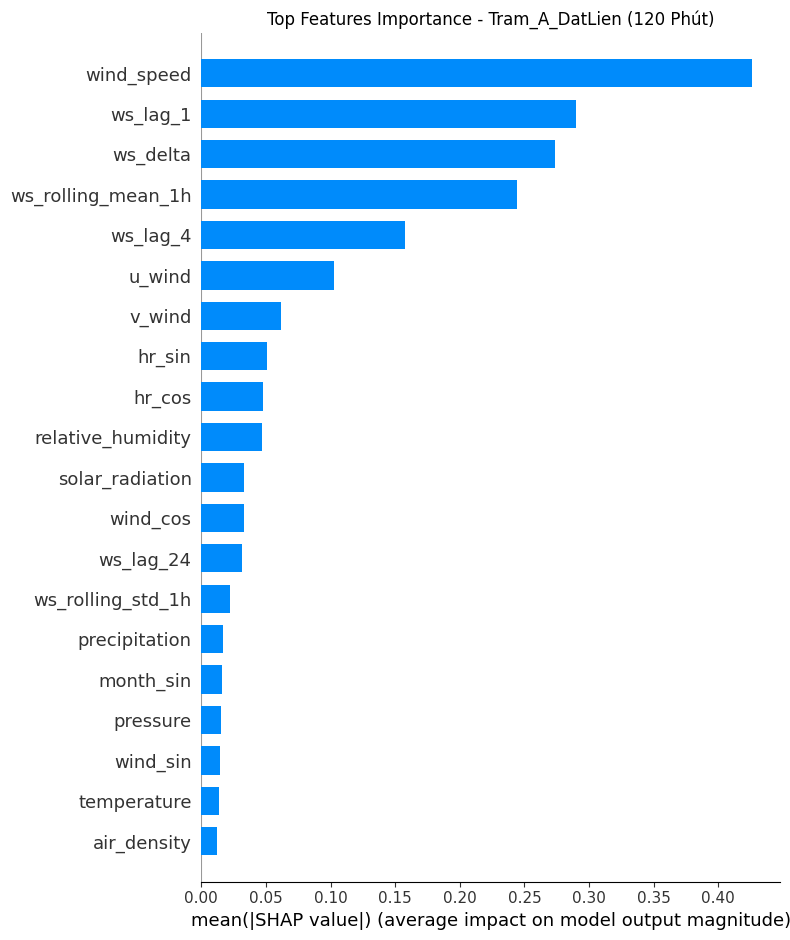

/tmp/ipykernel_490/749460926.py:87: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="dot", show=False)


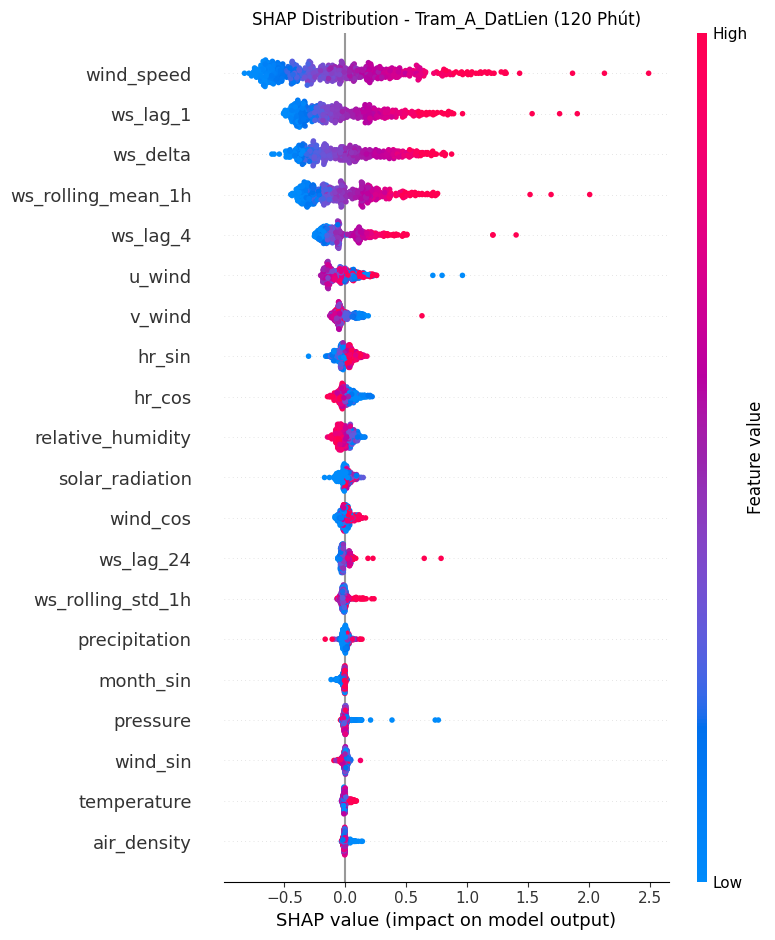

Phân tích mẫu sai số lớn nhất (Index: 101, Error: 4.1991)


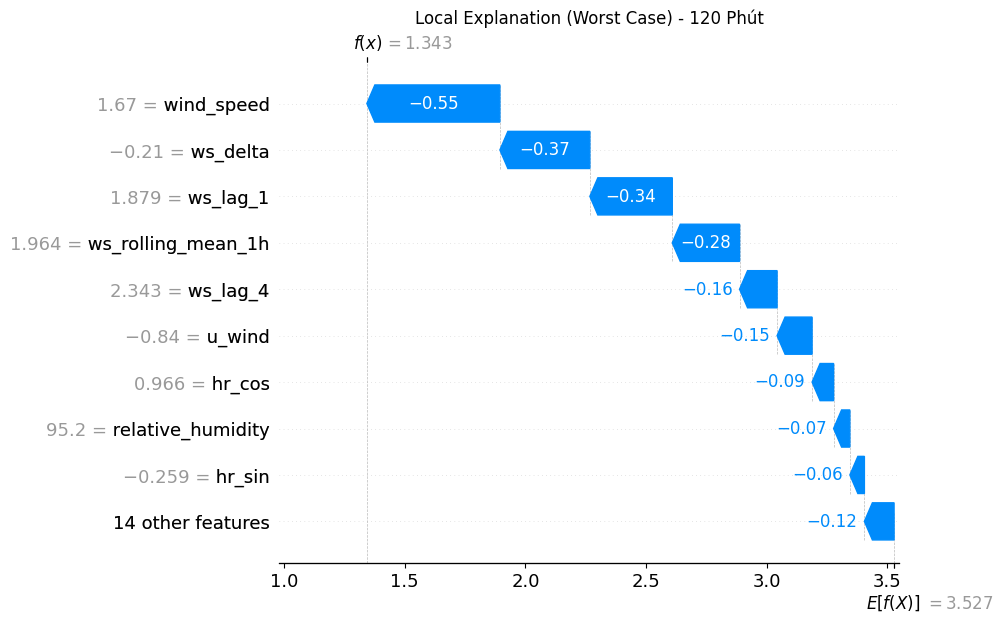


Future selection
Top 10 biến quan trọng nhất: 
['wind_speed', 'ws_lag_1', 'ws_rolling_mean_1h', 'ws_lag_4', 'ws_delta', 'u_wind', 'v_wind', 'ws_lag_24', 'wind_cos', 'ws_rolling_std_1h']

[Kết quả so sánh hiệu năng - mốc 30min
1. Mô hình Gốc (All Features): RMSE = 0.2479 | Latency = 0.0207 ms
2. Mô hình Lite (Top 10)     : RMSE = 0.1961 | Latency = 0.0212 ms
-> Độ trễ suy luận giảm được: -2.67%
Xử lý trạm: Tram_B_VenBien
Kích thước tập - Train: 73626 | Val: 15777 | Test: 15778

Đang huấn luyện mô hình...
Thời gian huấn luyện: 54.22s

Result test
Độ trễ suy luận trung bình (Latency): 0.0200 ms/mẫu
Horizon target_30min: RMSE = 0.1874 | MAE = 0.1247 | R2 = 0.9960
Horizon target_60min: RMSE = 0.3478 | MAE = 0.2475 | R2 = 0.9862
Horizon target_120min: RMSE = 0.6037 | MAE = 0.4561 | R2 = 0.9583

Global RMSE (All Horizons): 0.4165

Đang khởi tạo phân tích...

Vẽ biểu đổ SHAP cho mốc: 30 Phút


/tmp/ipykernel_490/749460926.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="bar", show=False)


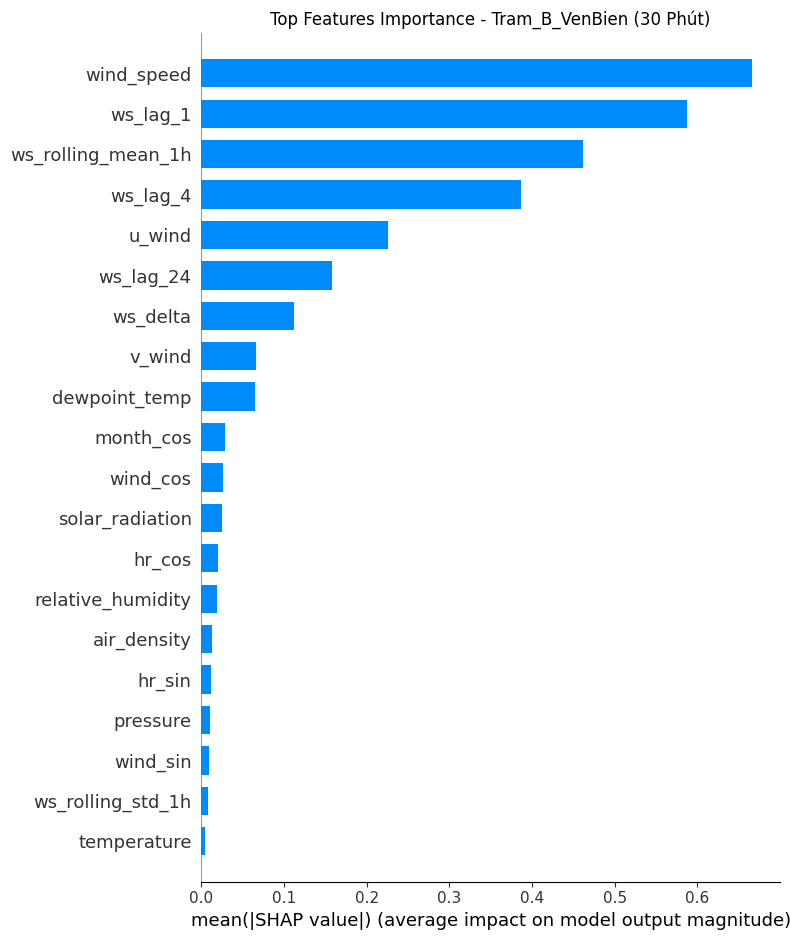

/tmp/ipykernel_490/749460926.py:87: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="dot", show=False)


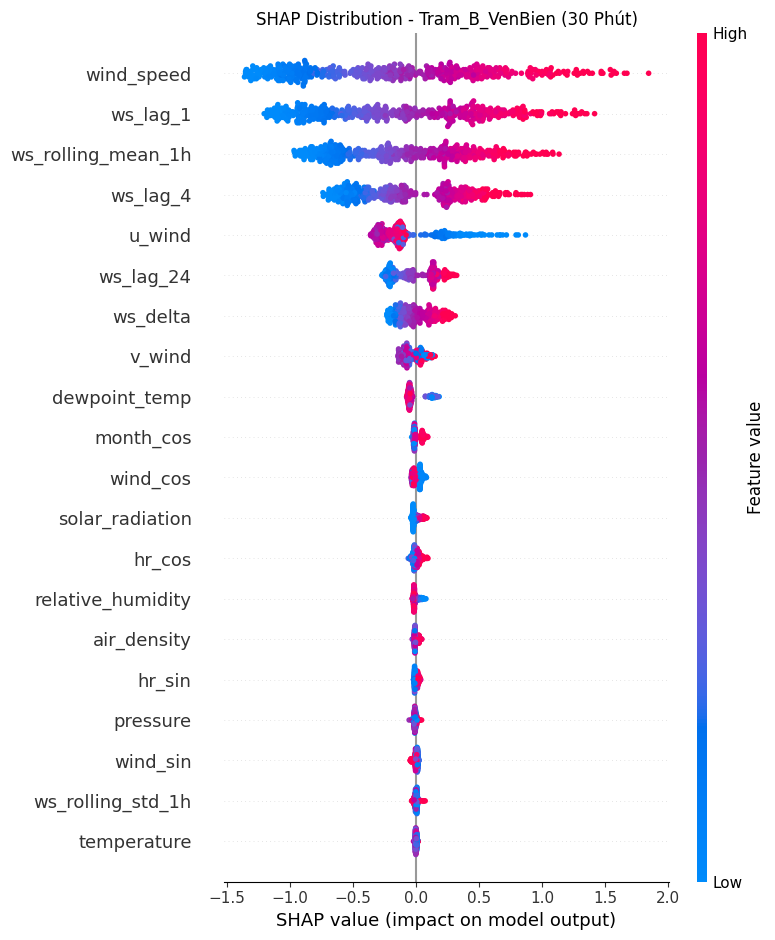

Phân tích mẫu sai số lớn nhất (Index: 71, Error: 1.4018)


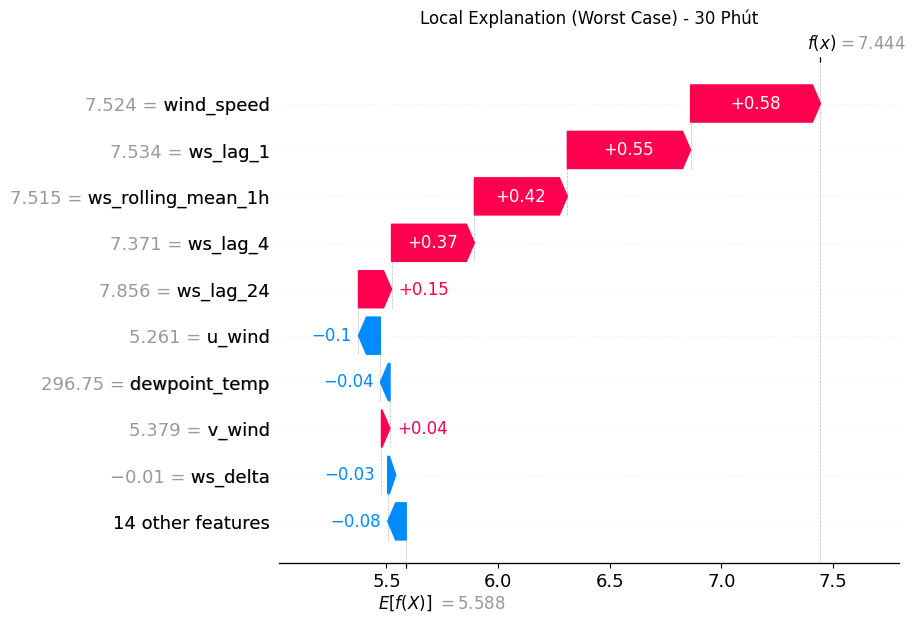


Vẽ biểu đổ SHAP cho mốc: 60 Phút


/tmp/ipykernel_490/749460926.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="bar", show=False)


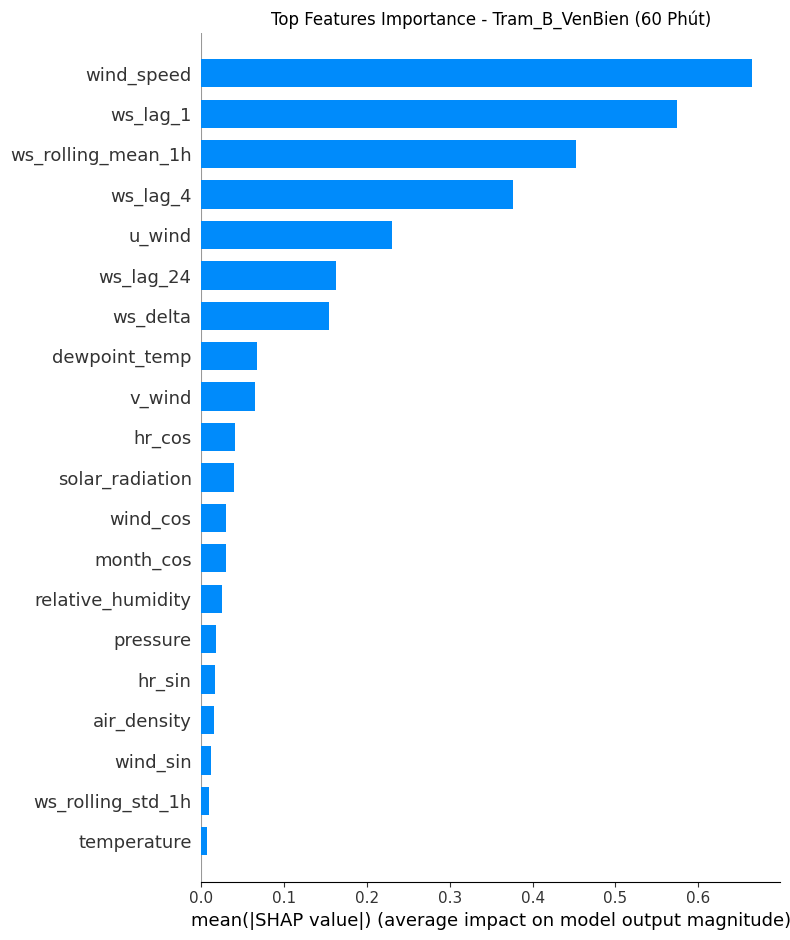

/tmp/ipykernel_490/749460926.py:87: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="dot", show=False)


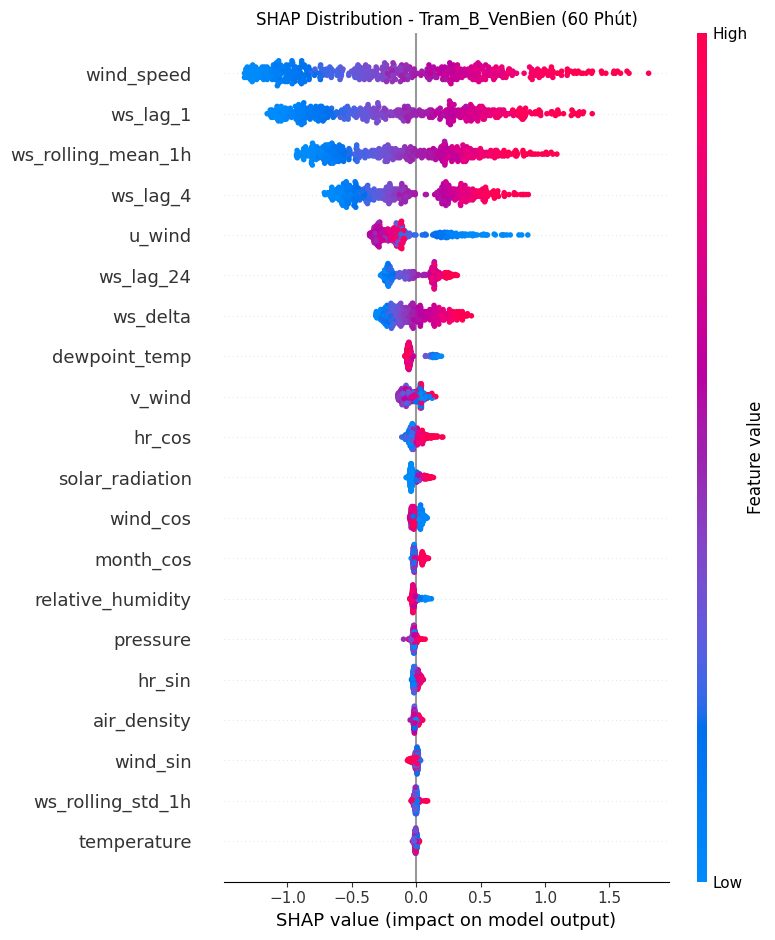

Phân tích mẫu sai số lớn nhất (Index: 69, Error: 1.7370)


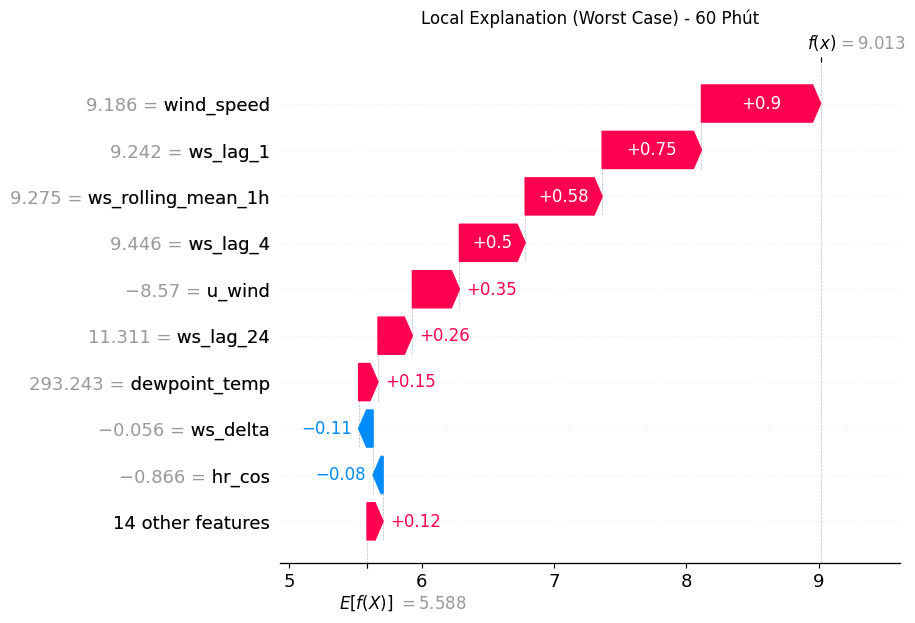


Vẽ biểu đổ SHAP cho mốc: 120 Phút


/tmp/ipykernel_490/749460926.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="bar", show=False)


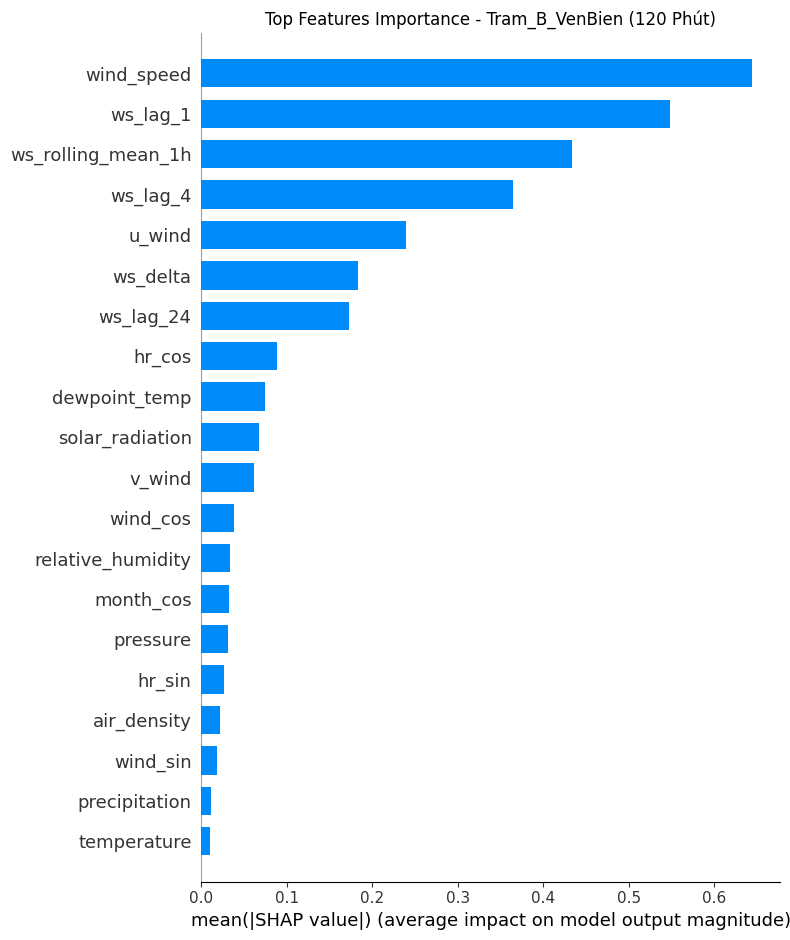

/tmp/ipykernel_490/749460926.py:87: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="dot", show=False)


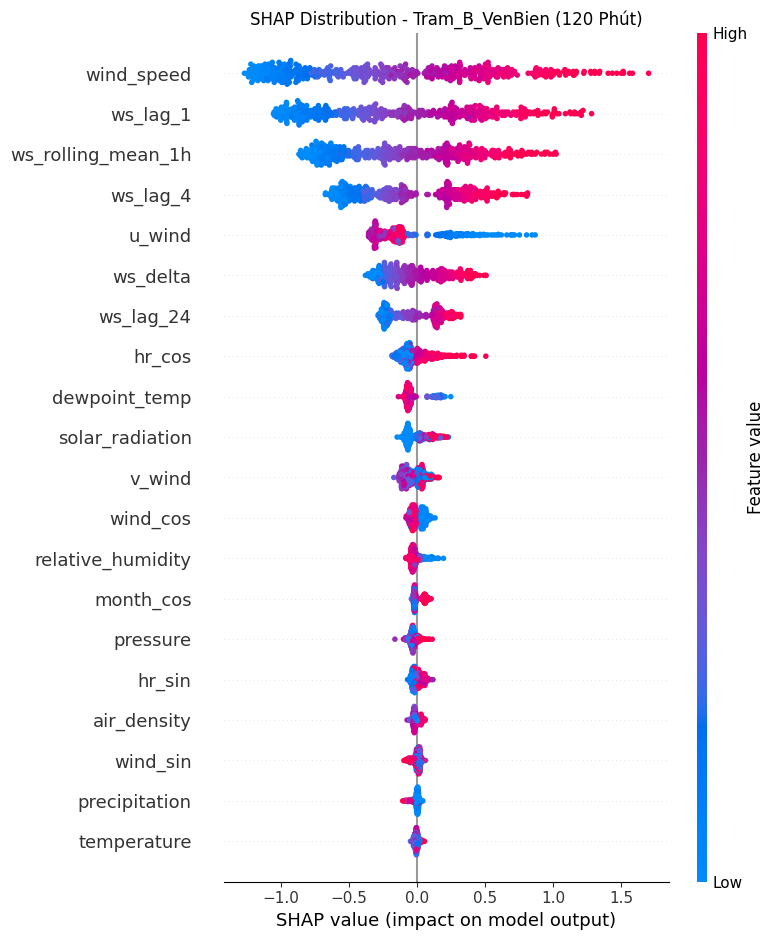

Phân tích mẫu sai số lớn nhất (Index: 49, Error: 2.4298)


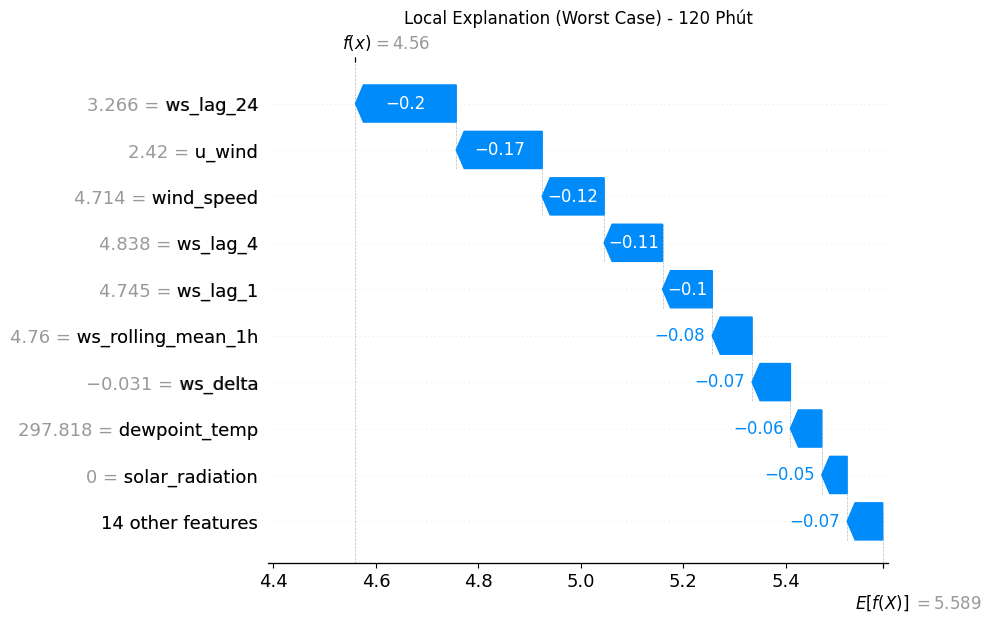


Future selection
Top 10 biến quan trọng nhất: 
['wind_speed', 'ws_lag_1', 'ws_rolling_mean_1h', 'ws_lag_4', 'u_wind', 'ws_lag_24', 'ws_delta', 'v_wind', 'dewpoint_temp', 'month_cos']

[Kết quả so sánh hiệu năng - mốc 30min
1. Mô hình Gốc (All Features): RMSE = 0.1874 | Latency = 0.0200 ms
2. Mô hình Lite (Top 10)     : RMSE = 0.1652 | Latency = 0.0201 ms
-> Độ trễ suy luận giảm được: -0.46%
Xử lý trạm: Tram_C_DoiNui
Kích thước tập - Train: 73559 | Val: 15763 | Test: 15763

Đang huấn luyện mô hình...
Thời gian huấn luyện: 52.70s

Result test
Độ trễ suy luận trung bình (Latency): 0.0405 ms/mẫu
Horizon target_30min: RMSE = 0.2618 | MAE = 0.1507 | R2 = 0.9907
Horizon target_60min: RMSE = 0.4544 | MAE = 0.3017 | R2 = 0.9719
Horizon target_120min: RMSE = 0.7469 | MAE = 0.5437 | R2 = 0.9239

Global RMSE (All Horizons): 0.5269

Đang khởi tạo phân tích...

Vẽ biểu đổ SHAP cho mốc: 30 Phút


/tmp/ipykernel_490/749460926.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="bar", show=False)


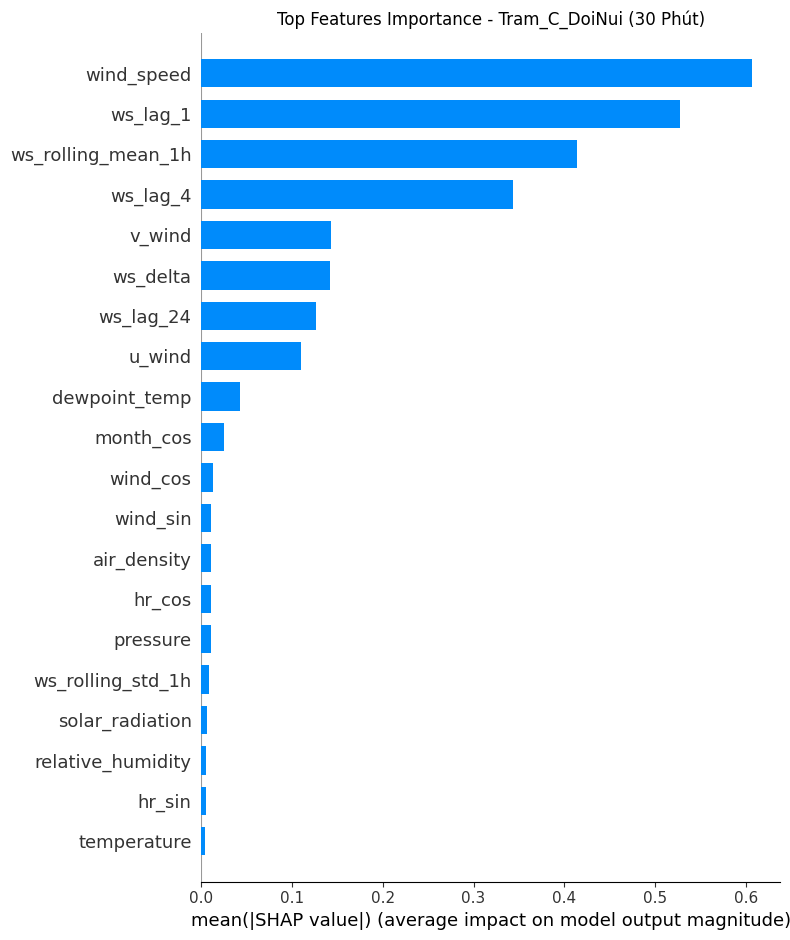

/tmp/ipykernel_490/749460926.py:87: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="dot", show=False)


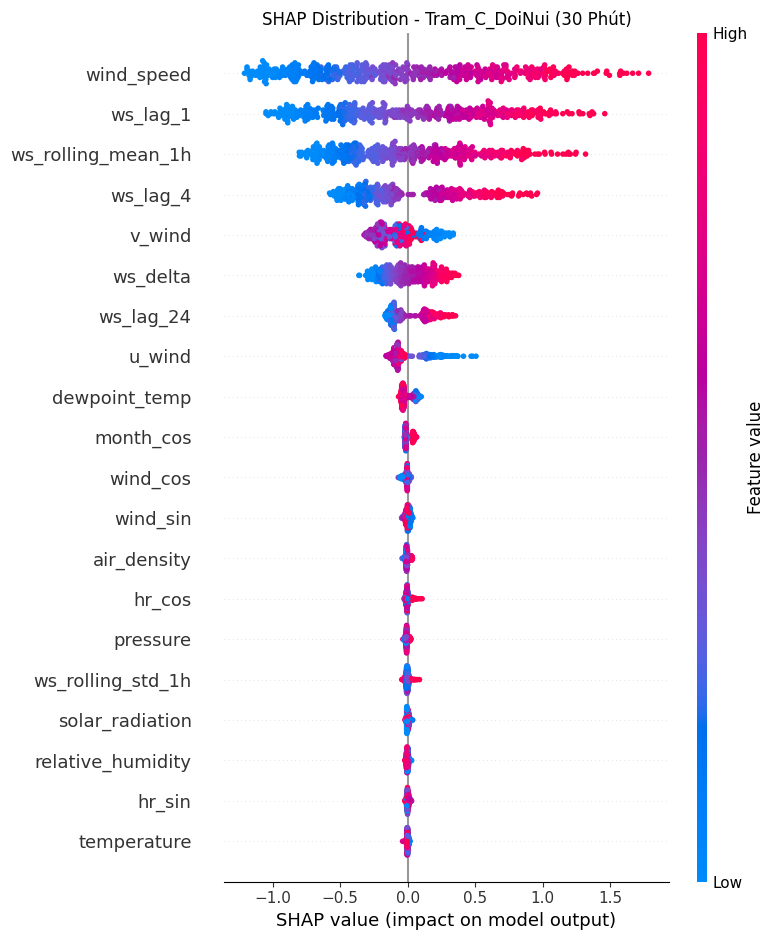

Phân tích mẫu sai số lớn nhất (Index: 64, Error: 2.0901)


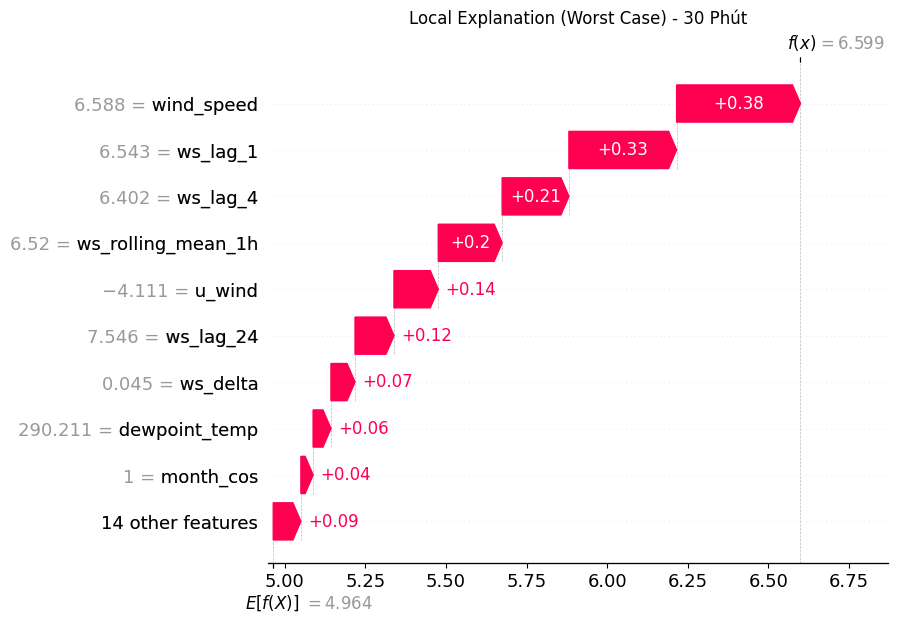


Vẽ biểu đổ SHAP cho mốc: 60 Phút


/tmp/ipykernel_490/749460926.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="bar", show=False)


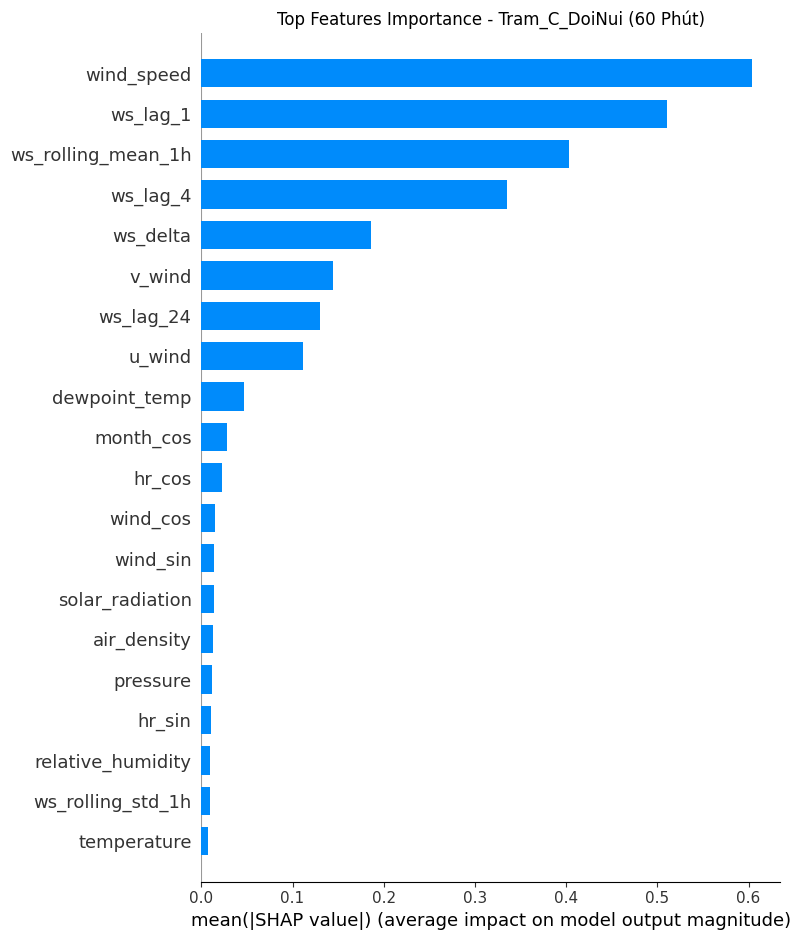

/tmp/ipykernel_490/749460926.py:87: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="dot", show=False)


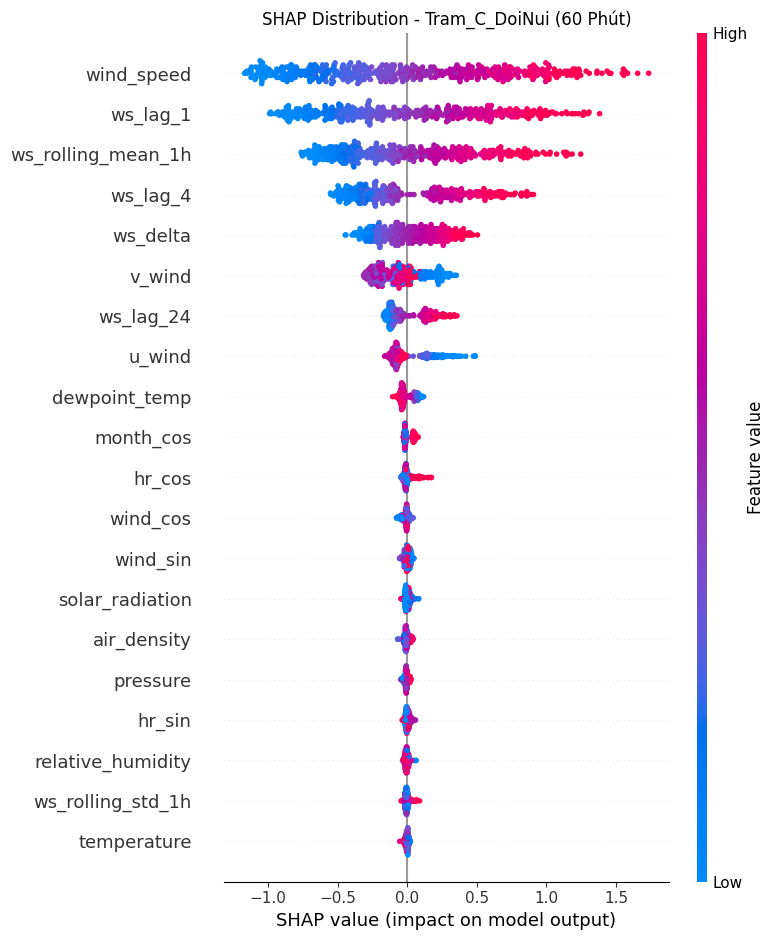

Phân tích mẫu sai số lớn nhất (Index: 354, Error: 3.0630)


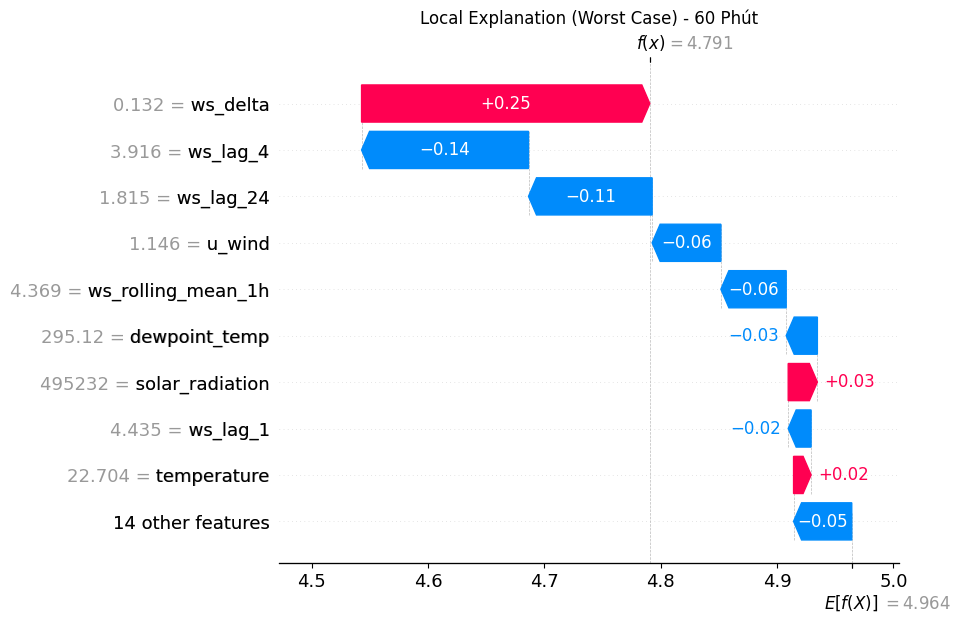


Vẽ biểu đổ SHAP cho mốc: 120 Phút


/tmp/ipykernel_490/749460926.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="bar", show=False)


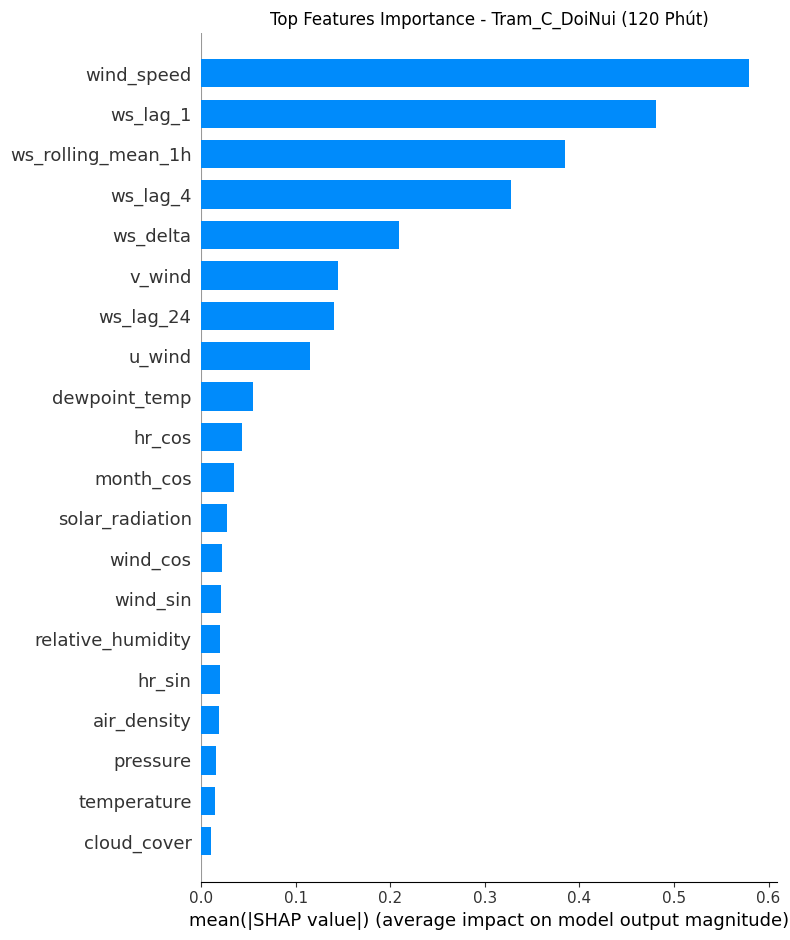

/tmp/ipykernel_490/749460926.py:87: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="dot", show=False)


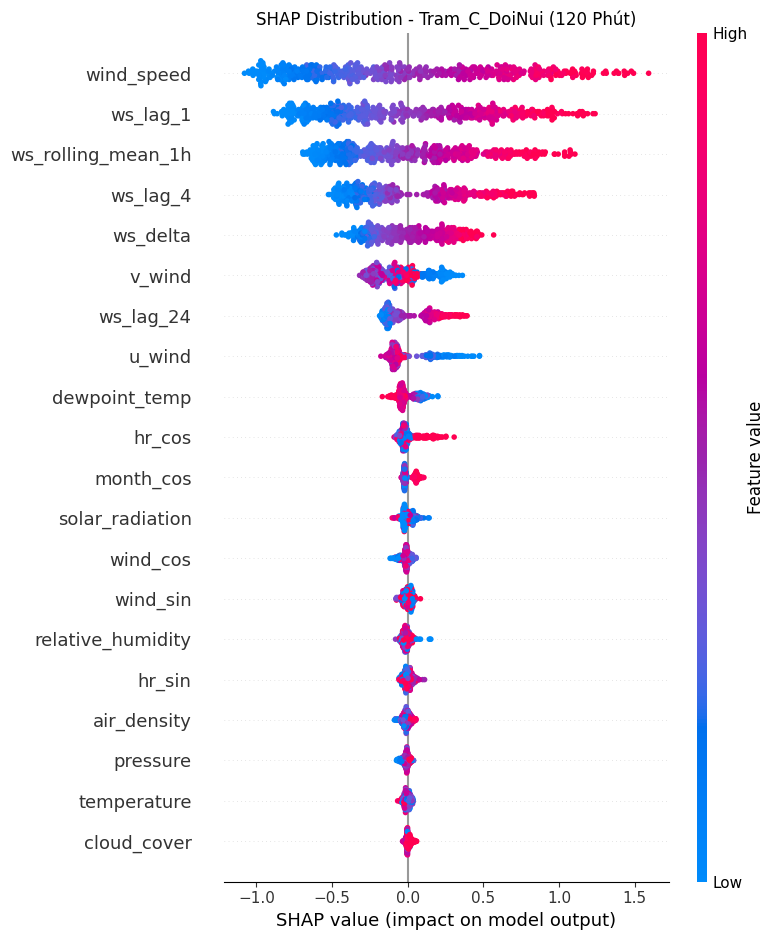

Phân tích mẫu sai số lớn nhất (Index: 58, Error: 3.8025)


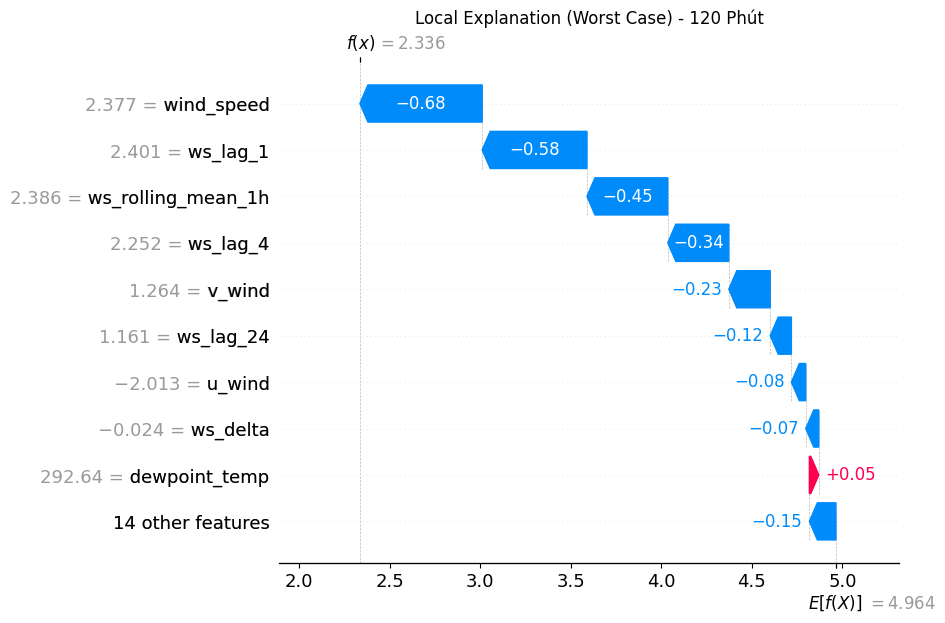


Future selection
Top 10 biến quan trọng nhất: 
['wind_speed', 'ws_lag_1', 'ws_rolling_mean_1h', 'ws_lag_4', 'v_wind', 'ws_delta', 'ws_lag_24', 'u_wind', 'dewpoint_temp', 'month_cos']

[Kết quả so sánh hiệu năng - mốc 30min
1. Mô hình Gốc (All Features): RMSE = 0.2618 | Latency = 0.0405 ms
2. Mô hình Lite (Top 10)     : RMSE = 0.2263 | Latency = 0.0204 ms
-> Độ trễ suy luận giảm được: 49.62%
Xử lý trạm: Tram_D_NgoaiKhoi
Kích thước tập - Train: 73626 | Val: 15777 | Test: 15778

Đang huấn luyện mô hình...
Thời gian huấn luyện: 54.76s

Result test
Độ trễ suy luận trung bình (Latency): 0.0212 ms/mẫu
Horizon target_30min: RMSE = 0.3106 | MAE = 0.1512 | R2 = 0.9942
Horizon target_60min: RMSE = 0.4790 | MAE = 0.2888 | R2 = 0.9862
Horizon target_120min: RMSE = 0.8301 | MAE = 0.5674 | R2 = 0.9585

Global RMSE (All Horizons): 0.5816

Đang khởi tạo phân tích...

Vẽ biểu đổ SHAP cho mốc: 30 Phút


/tmp/ipykernel_490/749460926.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="bar", show=False)


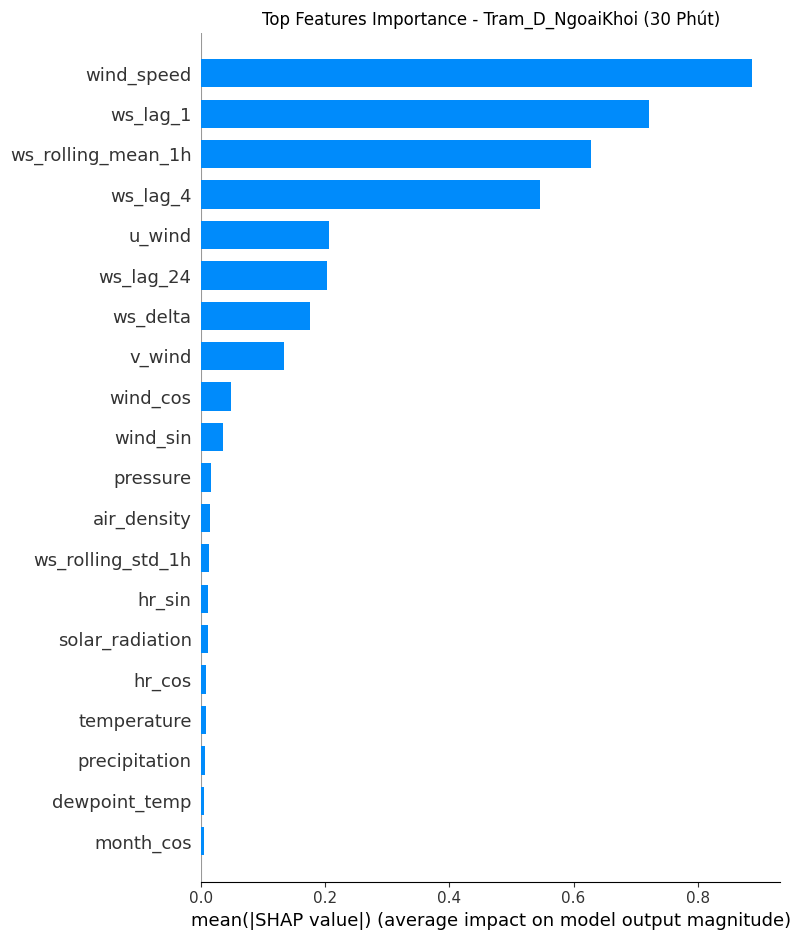

/tmp/ipykernel_490/749460926.py:87: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="dot", show=False)


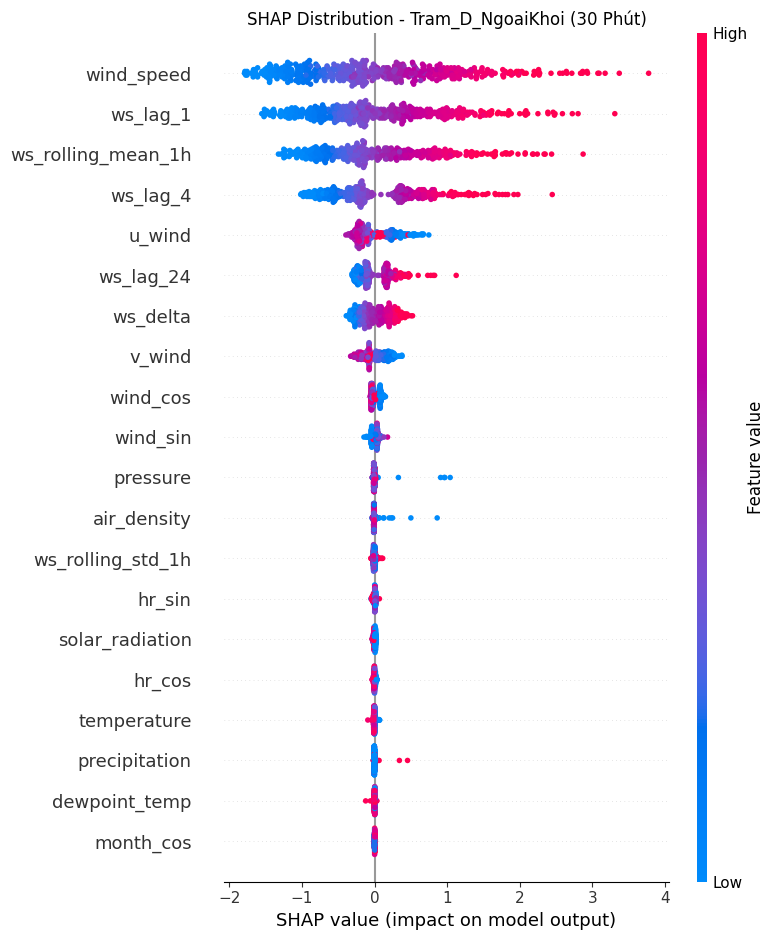

Phân tích mẫu sai số lớn nhất (Index: 178, Error: 3.5485)


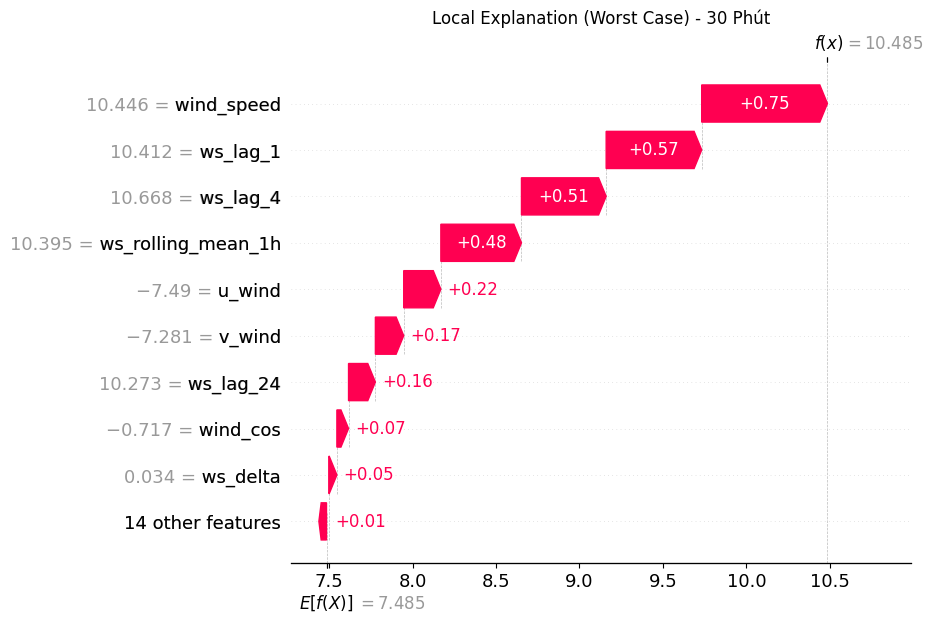


Vẽ biểu đổ SHAP cho mốc: 60 Phút


/tmp/ipykernel_490/749460926.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="bar", show=False)


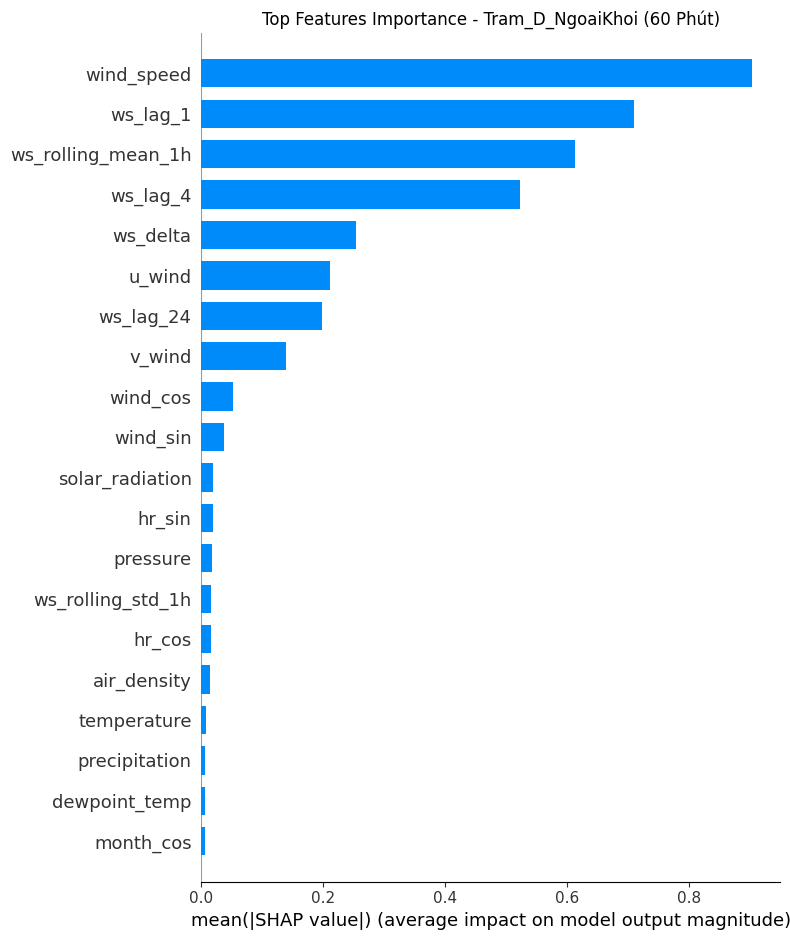

/tmp/ipykernel_490/749460926.py:87: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="dot", show=False)


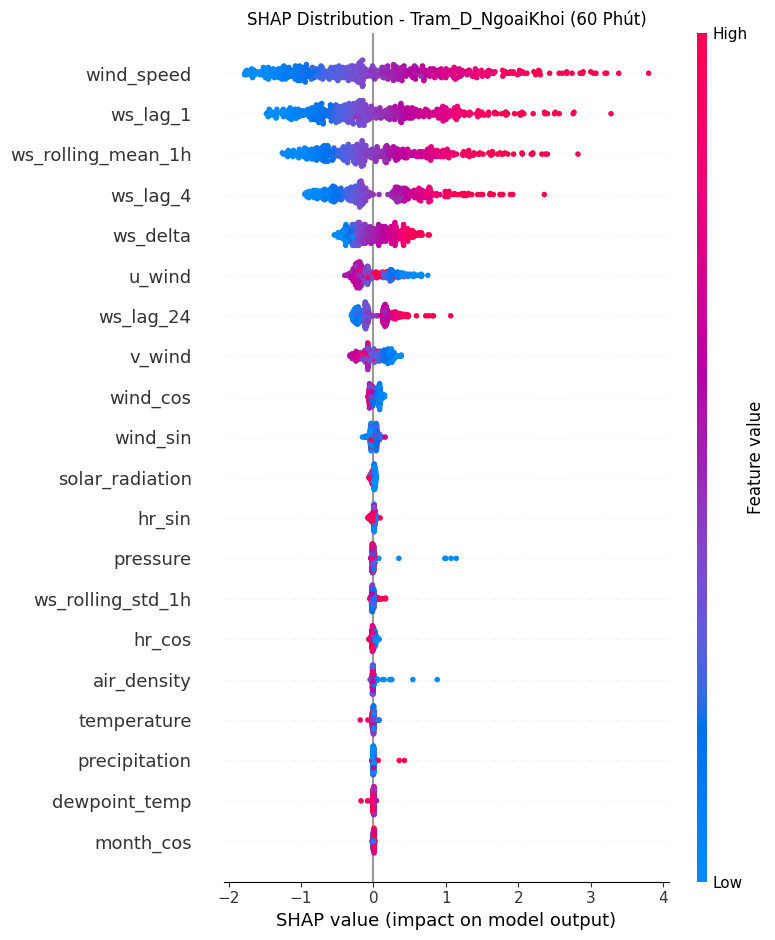

Phân tích mẫu sai số lớn nhất (Index: 33, Error: 4.5234)


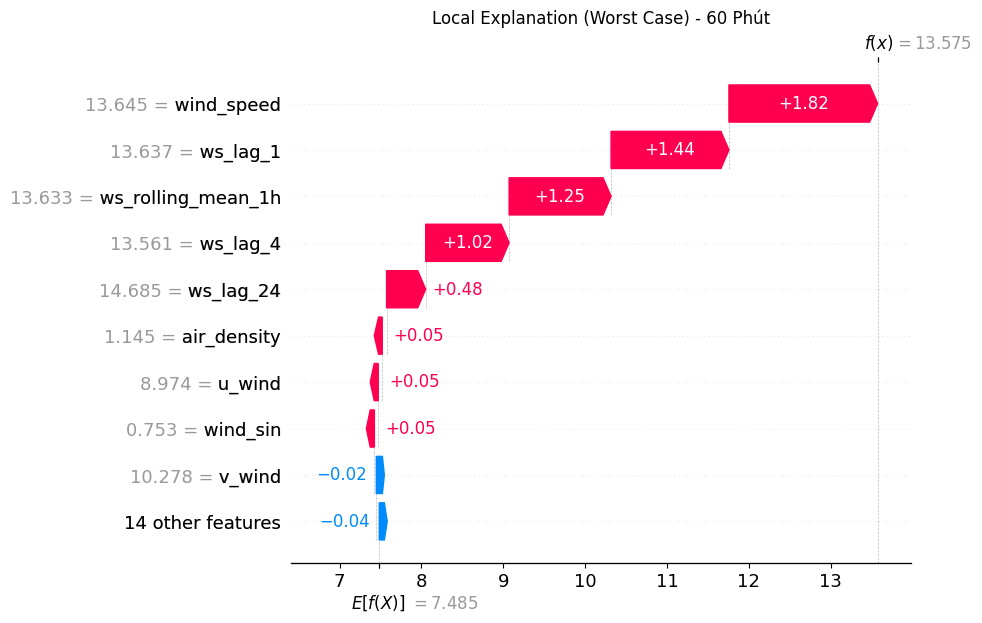


Vẽ biểu đổ SHAP cho mốc: 120 Phút


/tmp/ipykernel_490/749460926.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="bar", show=False)


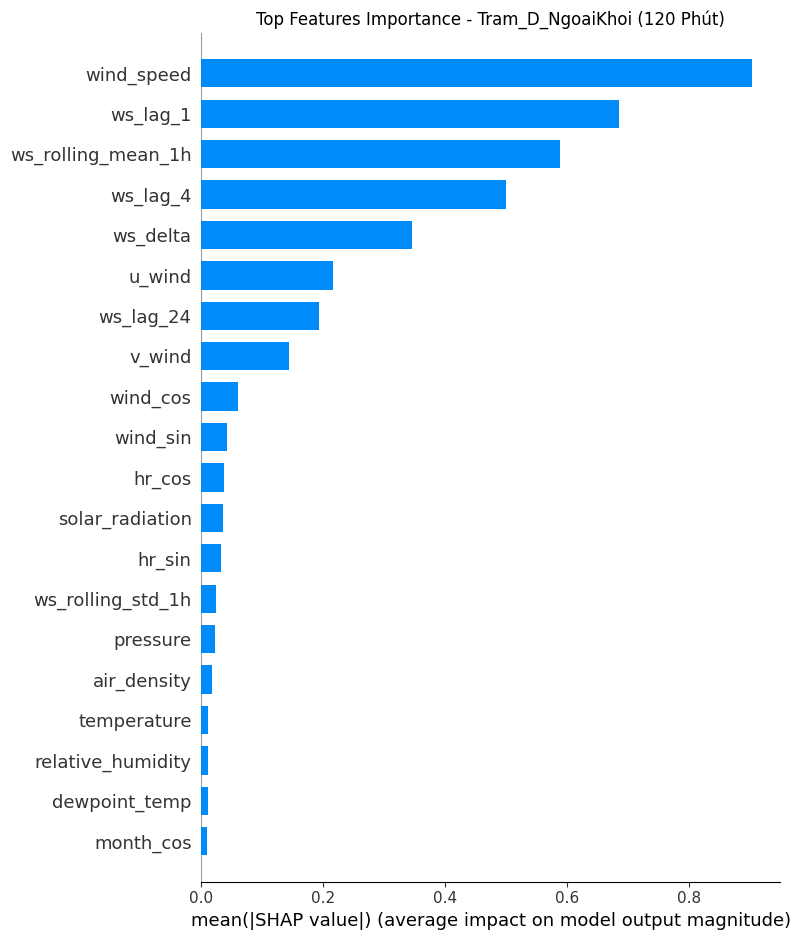

/tmp/ipykernel_490/749460926.py:87: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, plot_type="dot", show=False)


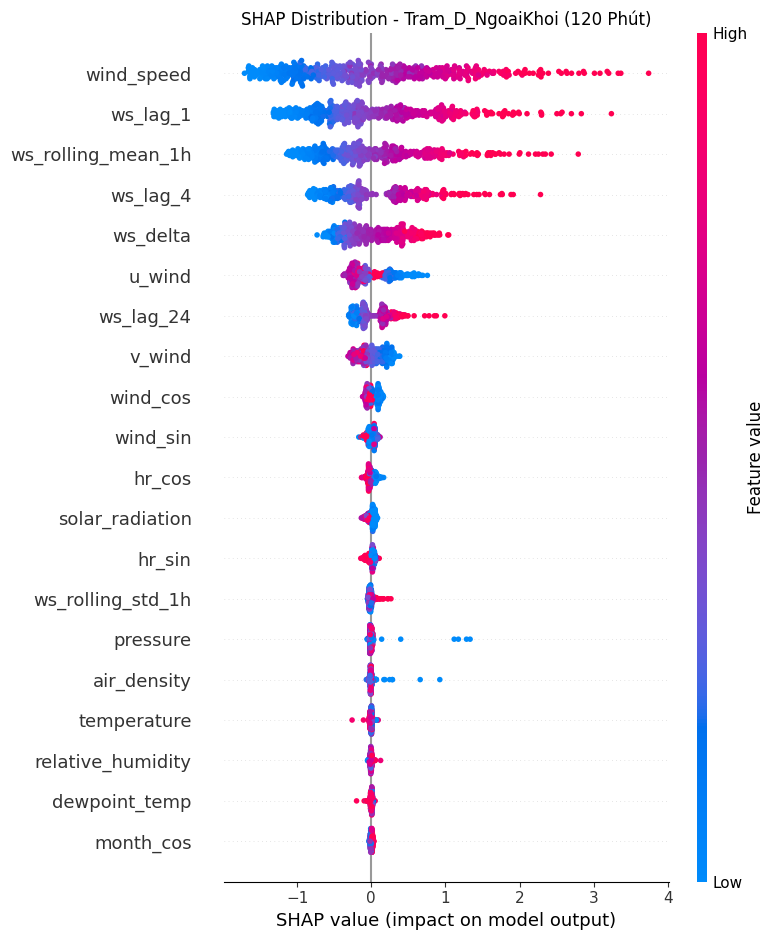

Phân tích mẫu sai số lớn nhất (Index: 105, Error: 6.5860)


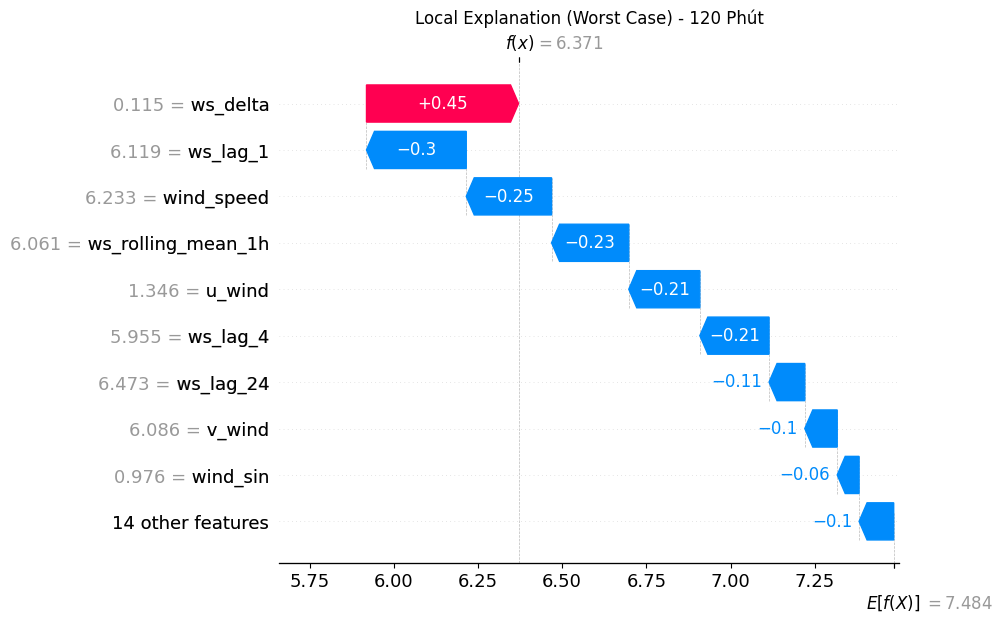


Future selection
Top 10 biến quan trọng nhất: 
['wind_speed', 'ws_lag_1', 'ws_rolling_mean_1h', 'ws_lag_4', 'u_wind', 'ws_lag_24', 'ws_delta', 'v_wind', 'wind_cos', 'wind_sin']

[Kết quả so sánh hiệu năng - mốc 30min
1. Mô hình Gốc (All Features): RMSE = 0.3106 | Latency = 0.0212 ms
2. Mô hình Lite (Top 10)     : RMSE = 0.1956 | Latency = 0.0204 ms
-> Độ trễ suy luận giảm được: 3.94%

Hoàn thành pipeline!
Tổng thời gian chạy: 32.14 phút


In [4]:
stations = ["Tram_A_DatLien",
            "Tram_B_VenBien",
            "Tram_C_DoiNui",
            "Tram_D_NgoaiKhoi"
            ]

base_path = "/content/drive/MyDrive/WIND_FORECAST_DATA/"

start_all = time.time()

for station in stations:
    path = f"{base_path}{station}_FINAL_MASTER.csv"

    train_randomforest(path, station, use_shap=True)

total_time = time.time() - start_all

print(f"\nHoàn thành pipeline!")
print(f"Tổng thời gian chạy: {total_time/60:.2f} phút")